In [22]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from PNW_cmap import PNW_cmap

from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.plotting.plot_session_heatmap import plot_glutamate_session


from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [23]:
%matplotlib notebook

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
today_str = datetime.today().strftime('%Y-%m-%d')

In [4]:
save_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"

In [5]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

In [6]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [7]:
for i,asset in enumerate(assets):
    print(i, asset.session_dir, f'depths: DMD1 = {asset.metadata["dmd1_depth"]}, DMD2 = {asset.metadata["dmd2_depth"]}' )

0 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496 depths: DMD1 = 25, DMD2 = 100
1 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-28_803496 depths: DMD1 = 25, DMD2 = 100
2 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-29_803496 depths: DMD1 = 25, DMD2 = 100
3 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-30_803496 depths: DMD1 = 25, DMD2 = 100
4 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-31_803496 depths: DMD1 = 25, DMD2 = 100
5 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-08-01_803496 depths: DMD1 = 25, DMD2 = 100
6 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\804730\2025-07-25_804730 depths: DMD1 = 25, DMD2 = 100
7 \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\804730\2025-07-28_804730 depths: DMD1 = 25, DMD2 = 100
8 \\alle

In [10]:
IM_COLORS = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8', '#9fd3f2'
]

In [42]:
asset = assets[21]
print(asset.session_id)

810196_2025-07-31_08-28-08


loaded data from \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\810196_2025-07-31_08-28-08_slap2_2026-01-16_17-12-16\source_extraction\ExperimentSummary\SummaryLoCo-260116-091428.mat


<IPython.core.display.Javascript object>


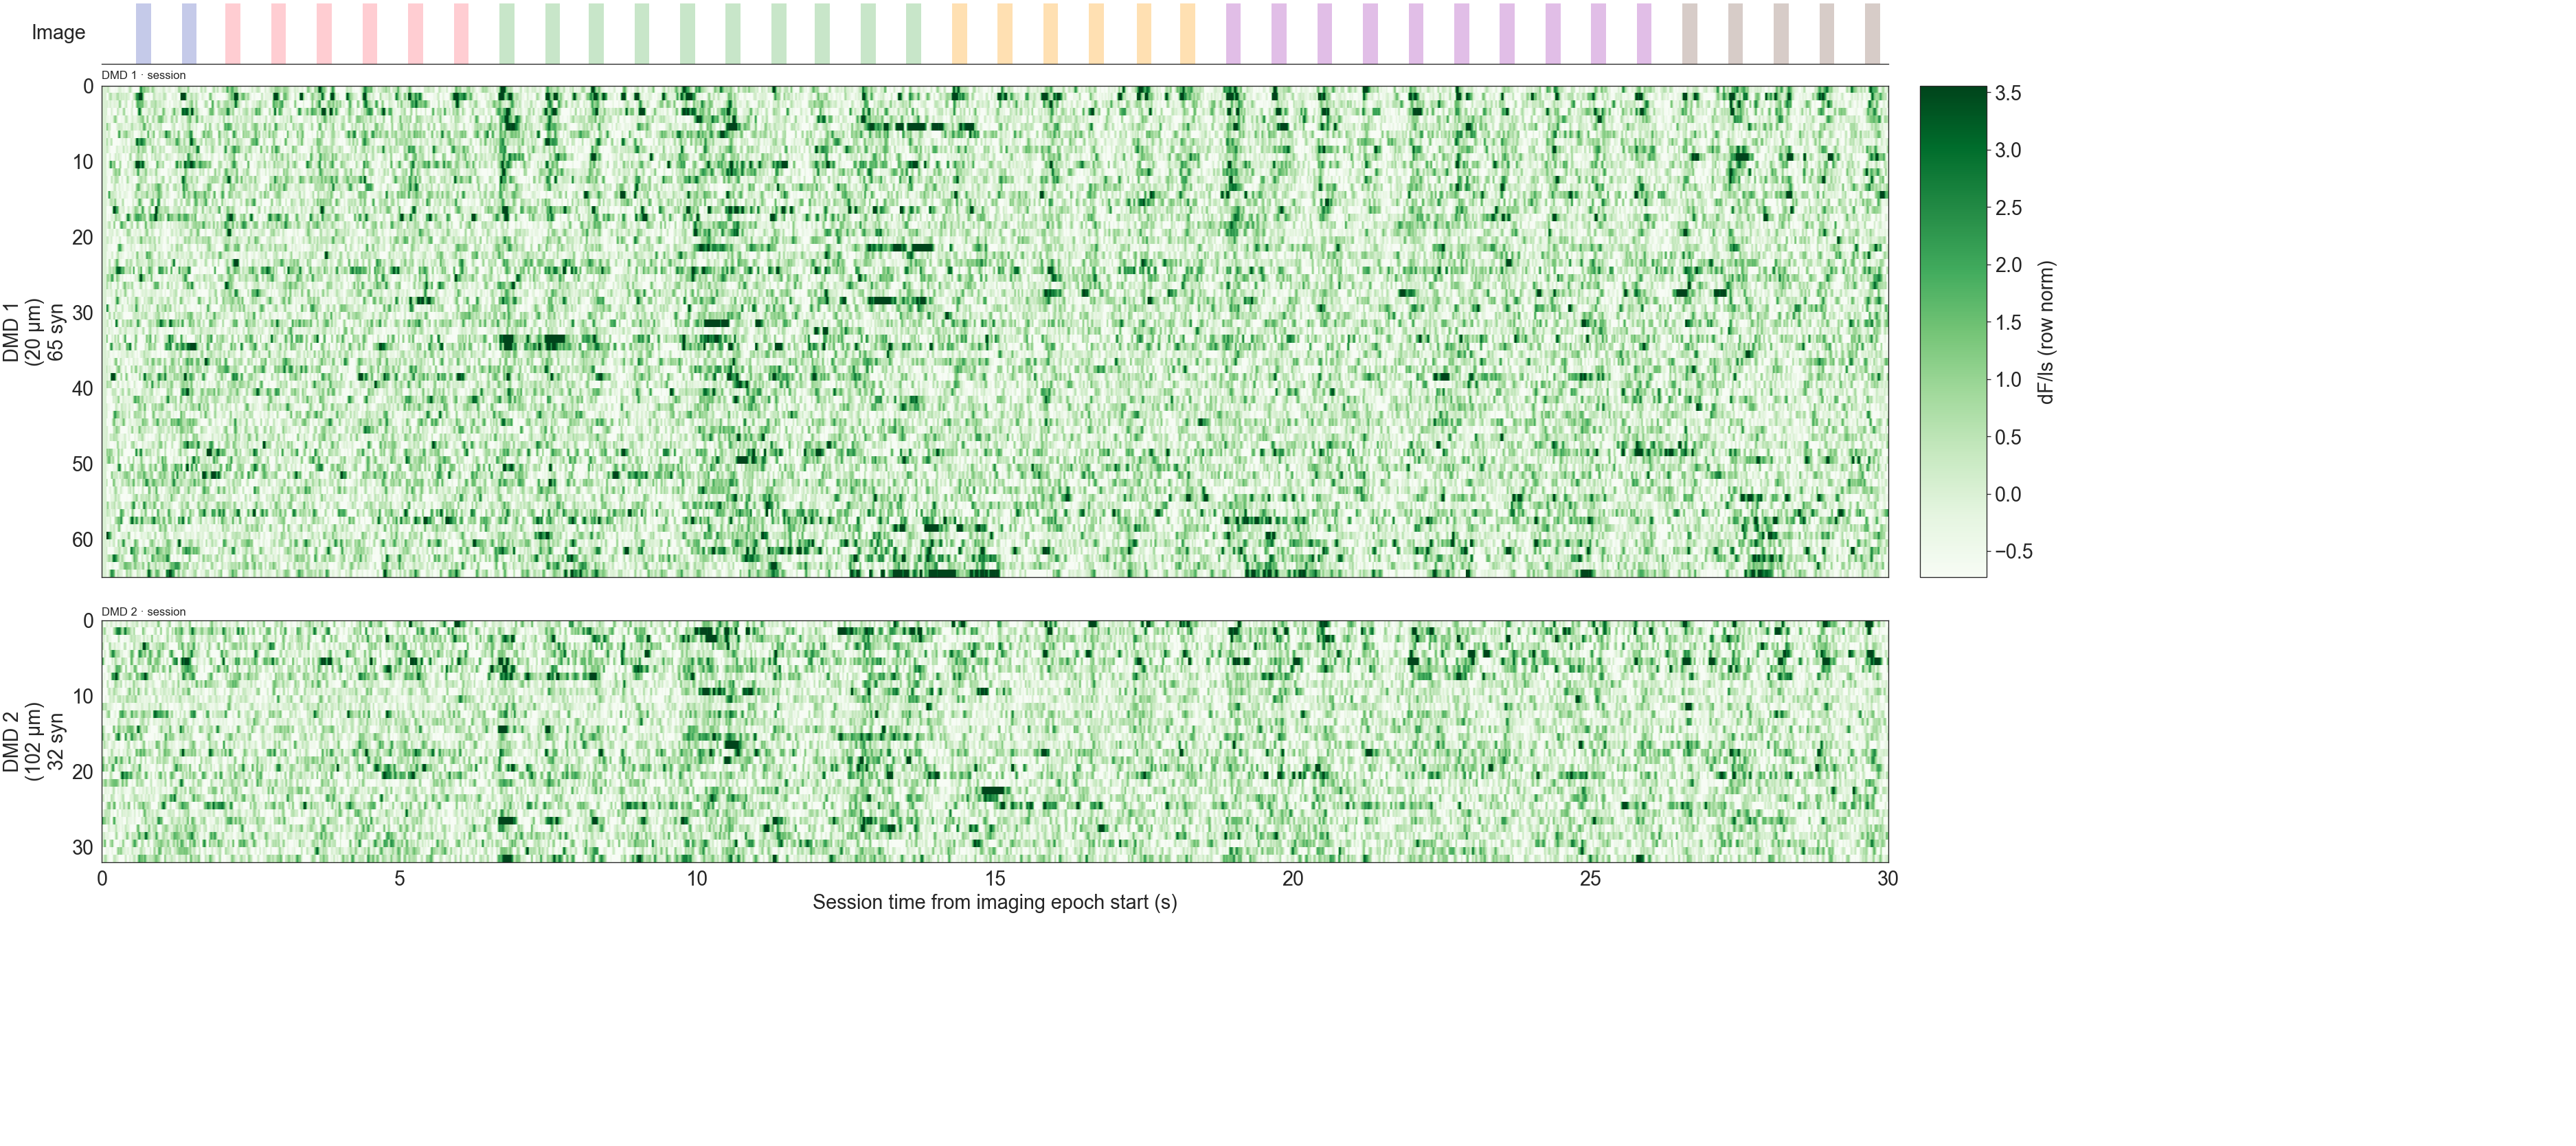

In [45]:
out = plot_glutamate_session(
    asset,
    signal="dF",
    mode="ls",
    channels="glutamate",
    xlim_sec=(0,30),
    normalize_rows='zscore',
    display_smooth_sigma=3,
    feature_smooth_sigma=2.0,
    sort_by="pc1_raw", #
    t_pre=0.5,
    t_post=1.0,
    baseline_subtract=True,
    baseline_window=(-0.25, 0.0),
    show_image_bar=True,
    show_whole_session=True,
    show_pooled_stimulus_heatmap=False,
    show_per_image_heatmap=False,
    cmap_session="Greens",
    cmap_feature="coolwarm",
    session_percentiles=(10, 99),
    feature_percentiles=(10, 99),
    image_flash_duration=0.25,
    im_colors=IM_COLORS,
    figsize_width=25,
    synapse_height=0.1,
    min_whole_height=0.5,
    pooled_height=0.75,
    per_image_height=0.75,
    image_bar_height=0.8,
    dmd_gap_height=0.22,
    show_titles=False,
    show_row_labels=True,
    max_image_label_len=16,
)

filen = f'{today_str}_{asset.session_id}_heatmap'
# save_figure(out['fig'],os.path.join(save_path,filen),formats=['.pdf'],dpi=300)